# Top-Decile Condition: Which Threshold?

Backtest condition of the delivery plan (T10): **mean top-decile precision >= 1.5x the recency rule**. Every brand fails it. The KPI stays (the ratio of the model's top-decile precision to the recency rule's); only its threshold is lowered. Which value? Data: the latest completed backtest of brands 14, 64 and 73 (`make backtest`), 11 monthly cutoffs each.

In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

BACKTESTS = Path("..").resolve() / "data/03_output/backtest"
BRANDS = (14, 64, 73)
THRESHOLDS = (1.05, 1.10, 1.15, 1.20, 1.25, 1.30)
odds = lambda p: p / (1 - p)

parts = []
for b in BRANDS:
    path = sorted(BACKTESTS.glob(f"backtest_brand{b}_*_metrics.csv"))[-1]  # a running backtest has no metrics yet
    parts.append(pd.read_csv(path).assign(brand=b))
precision = (pd.concat(parts).pivot_table(index=["brand", "cutoff"], columns="comparator", values="top_decile_precision")
             [["recency", "lgbm_optimised", "cox", "incumbent"]])
mean = precision.groupby("brand").mean()
pd.DataFrame({"recency": mean["recency"], "model": mean["lgbm_optimised"],
              "ratio (plan: >= 1.5)": mean["lgbm_optimised"] / mean["recency"],
              "most a perfect model can reach": 1 / mean["recency"]}).round(3)

,recency,model,ratio (plan: >= 1.5),most a perfect model can reach
brand,,,,
14,0.737,0.875,1.186,1.356
64,0.713,0.861,1.209,1.403
73,0.740,0.919,1.241,1.351


## 1. 1.5x Cannot Be Met

Precision cannot exceed 1, so the ratio is at most **1 / recency precision**. With a 60-day churn rate of 30% to 70%, the players silent for weeks are almost all churners: recency alone is already 71% to 74% precise, so the ceiling is 1.35x to 1.40x. Not even a perfect model passes 1.5x.

## 2. The Ceiling Moves with the Season

When churn rises, recency becomes more precise and the ceiling falls (dashed line); each dot is the model on one brand and cutoff. Measuring on another scale (the odds, p / (1 - p)) would remove the ceiling, but it changes the KPI, so it is set aside: the KPI stays and the threshold must leave room under the ceiling in every season.

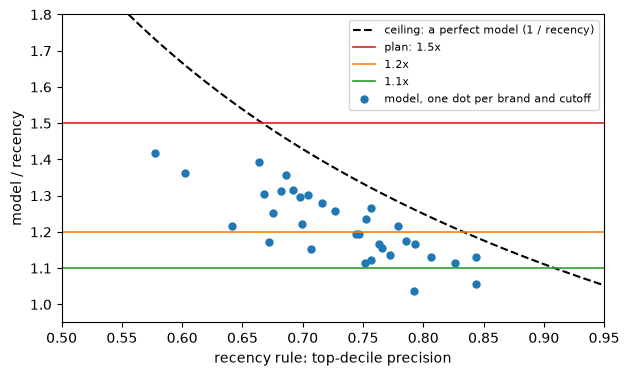

In [24]:
rec, ratio = precision["recency"], precision["lgbm_optimised"] / precision["recency"]
grid = np.linspace(0.5, 0.95, 100)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, 1 / grid, color="black", ls="--", label="ceiling: a perfect model (1 / recency)")
for t, colour, label in ((1.5, "#d62728", "plan: 1.5x"), (1.2, "#ff7f0e", "1.2x"), (1.1, "#2ca02c", "1.1x")):
    ax.axhline(t, color=colour, lw=1.2, label=label)
ax.scatter(rec, ratio, color="#1f77b4", s=25, label="model, one dot per brand and cutoff")
ax.set(xlim=(0.5, 0.95), ylim=(0.95, 1.8), xlabel="recency rule: top-decile precision", ylabel="model / recency")
ax.legend(fontsize=8, loc="upper right")
plt.show()

## 3. Which Value

For each threshold: does the model pass on the mean of its cutoffs (the KPI), does it pass **with 95% confidence** (the lower end of the bootstrap interval, cutoffs resampled, is above the threshold), and on what share of the cutoffs taken one by one. The last two columns say what each threshold asks, to compare it with the plan: the share of the possible gain over recency (from 1x to the ceiling), and the same demand in churners per wasted contact (odds ratio, the plan's 1.5 being its intent).

In [25]:
rng = np.random.default_rng(0)
low = {}
for b in BRANDS:
    p = precision.loc[b]
    boots = [s["lgbm_optimised"] / s["recency"] for s in (p.iloc[rng.integers(0, len(p), len(p))].mean() for _ in range(2000))]
    low[b] = np.percentile(boots, 2.5)
model_ratio = mean["lgbm_optimised"] / mean["recency"]
per_cutoff = precision["lgbm_optimised"] / precision["recency"]
r = mean["recency"].mean()
rows = []
for t in THRESHOLDS:
    rows.append({"threshold": t,
                 "brands passing (mean)": f"{sum(model_ratio >= t)} of 3",
                 "brands passing with 95% confidence": f"{sum(v >= t for v in low.values())} of 3",
                 **{f"cutoffs passing, brand {b}": f"{(per_cutoff.loc[b] >= t).mean():.0%}" for b in BRANDS},
                 "share of the possible gain asked": f"{((t - 1) / (1 / mean['recency'] - 1)).mean():.0%}",
                 "odds ratio asked": round(odds(t * r) / odds(r), 2)})
display(pd.DataFrame(rows).set_index("threshold"))
print("model ratio:", model_ratio.round(3).to_dict(), "| lower end of the 95% interval:", {b: round(v, 3) for b, v in low.items()})
print("other scores: Cox", (mean["cox"] / mean["recency"]).round(2).to_dict(),
      "| platform churn_score", (mean["incumbent"] / mean["recency"]).round(2).to_dict())

,brands passing (mean),brands passing with 95% confidence,"cutoffs passing, brand 14","cutoffs passing, brand 64","cutoffs passing, brand 73",share of the possible gain asked,odds ratio asked
threshold,,,,,,,
1.05,3 of 3,3 of 3,91%,100%,100%,14%,1.21
1.10,3 of 3,3 of 3,82%,100%,100%,27%,1.51
1.15,3 of 3,2 of 3,64%,82%,82%,41%,1.93
1.20,2 of 3,0 of 3,45%,45%,64%,54%,2.61
1.25,0 of 3,0 of 3,27%,36%,55%,68%,3.86
1.30,0 of 3,0 of 3,27%,9%,36%,81%,6.89


model ratio: {14: 1.186, 64: 1.209, 73: 1.241} | lower end of the 95% interval: {14: np.float64(1.132), 64: np.float64(1.169), 73: np.float64(1.188)}
other scores: Cox {14: 1.17, 64: 1.2, 73: 1.24} | platform churn_score {14: 0.72, 64: 0.53, 73: 0.57}


- **1.20 and above**: brand 14 fails (1.19), and brand 64 passes only by chance (its interval goes down to 1.17).
- **1.15**: every brand passes on the mean, but brand 14 not with confidence (interval down to 1.13).
- **1.10**: every brand passes with confidence (lower ends 1.13, 1.17, 1.19). It asks for about a quarter of the possible gain, which is the plan's own demand: with recency at today's precision, 1.5x churners per wasted contact is a precision ratio of 1.10.
- **1.05**: too lax, it asks for only 14% of the possible gain.

## 4. Decision

**Mean top-decile precision >= 1.10x the recency rule.** It is the strictest round value the model meets with 95% confidence in every brand, and it keeps the plan's intent at today's churn rates. It separates the scores that add something to recency (the model, Cox) from the platform's `churn_score` (0.53x to 0.72x). It cannot tell the model from simple two-variable rules, which also reach about 1.13x to 1.22x in the top decile: no value of this KPI can.